- import libraries and tools 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()



- read and run dataset 

In [2]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
df.shape

(1470, 35)

- the  dataset we have consists of `1470` rows and `35` columns , at frist glance it looks like a clean dataset.

## 🎯 Project Objective
- Build a **Binary Classification** model to predict attrition (Yes/No)
- Identify the **most important features** driving employee attrition
- Provide **actionable insights** to HR teams to reduce turnover rate
- Handle **Class Imbalance** using proper techniques (SMOTE / class weighting)

## 📊 Target Variable 
- **Target column:** `Attrition`
- **Values:** `Yes` (employee left) / `No` (employee stayed)
- **Problem type:** Binary Classification
- **Main challenge:** Class Imbalance (~16% Yes vs ~84% No)

## 📈 Success Metrics 
Since the dataset is imbalanced, primary evaluation metrics:
- **ROC-AUC Score** — primary metric
- **F1-Score** — especially for the minority class (Yes)
- **Precision & Recall** — balance between both
- **Confusion Matrix** — full error analysis

## 💡 Expected Output 
Final model output:
1. Probability of attrition for each employee (0 to 1)
2. Top contributing features using **SHAP Values**
3. Actionable HR recommendations based on model findings

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

- column categories :  

- **personal information** :  Age، Gender، MaritalStatus، Education، EducationField 
- **job and organization** : Department، JobRole، JobLevel، BusinessTravel، OverTime
- **Financial** : MonthlyIncome، HourlyRate، DailyRate، MonthlyRate، PercentSalaryHike، StockOptionLevel
- **work history** : TotalWorkingYears، YearsAtCompany، YearsInCurrentRole، YearsSinceLastPromotion، YearsWithCurrManager، NumCompaniesWorked
- **satisfaction and performance**: JobSatisfaction، EnvironmentSatisfaction، RelationshipSatisfaction، WorkLifeBalance، PerformanceRating، JobInvolvement، TrainingTimesLastYear


In [7]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

- deleting columns that don't give us specific information 

In [10]:
df.drop(['Over18','EmployeeNumber','EmployeeCount','StandardHours'],axis=1,inplace=True)

In [11]:
# target column 
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [12]:
print(df['Attrition'].unique())

[1 0]


In [13]:
print(df['Attrition'].unique())
print(df['Attrition'].dtype)

[1 0]
int64


In [14]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df['Attrition'].unique())

['Yes' 'No']


In [15]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].unique())

[1 0]


In [16]:
df.drop(['Over18','EmployeeNumber','EmployeeCount','StandardHours'],axis=1,inplace=True)

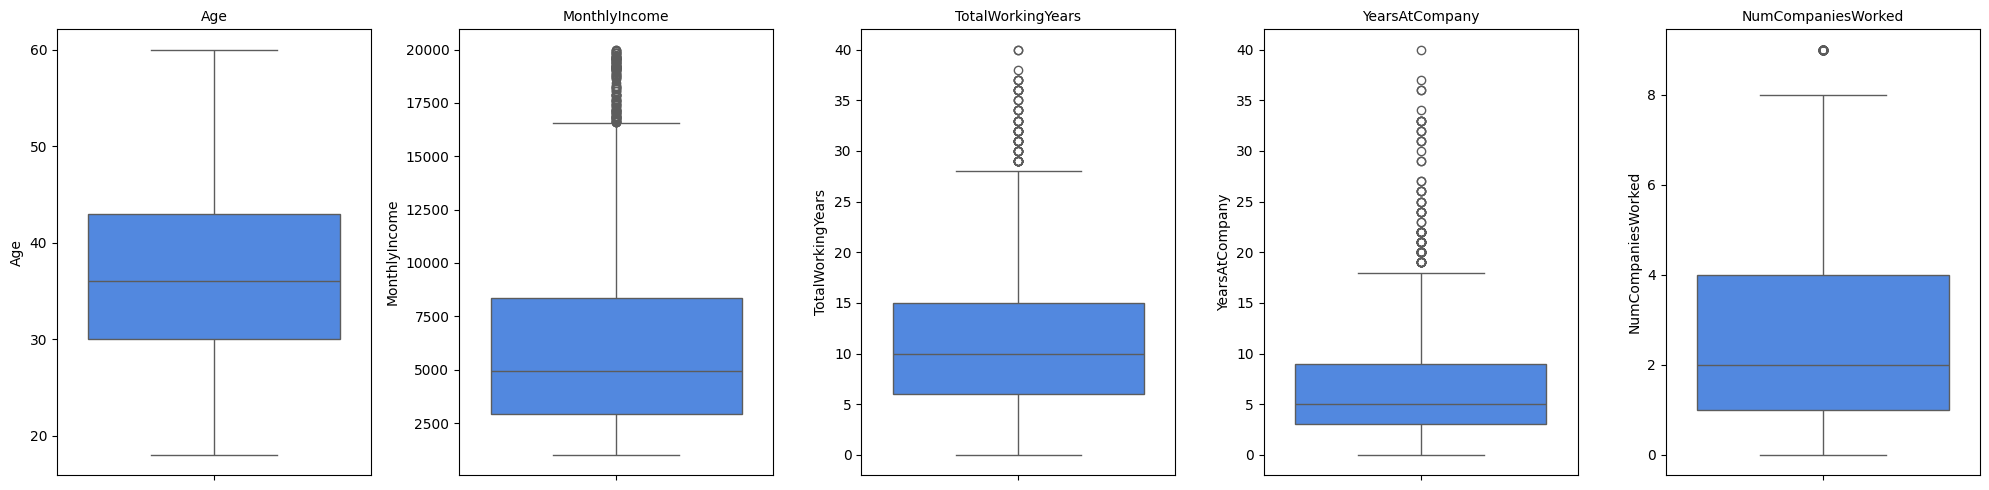

In [17]:

cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 
        'YearsAtCompany', 'NumCompaniesWorked']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#3B82F6')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

cols_to_clean = ['MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked']

for col in cols_to_clean:
    df = remove_outliers_iqr(df, col)

In [19]:
df.shape

(1470, 31)

In [20]:
print(df.select_dtypes(include='object').columns.tolist())

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['OverTime'] = le.fit_transform(df['OverTime'])

In [22]:
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 
                                  'EducationField', 'JobRole', 
                                  'MaritalStatus'], drop_first=True)

In [23]:

print(df.dtypes.value_counts())

int64      24
bool       19
float64     2
Name: count, dtype: int64


In [24]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
print(df.dtypes.value_counts())

int64      43
float64     2
Name: count, dtype: int64


In [25]:
print(df.shape)
print(df['Attrition'].value_counts())

(1470, 45)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [26]:
df.shape

(1470, 45)

**done encoding**

**start EDA**

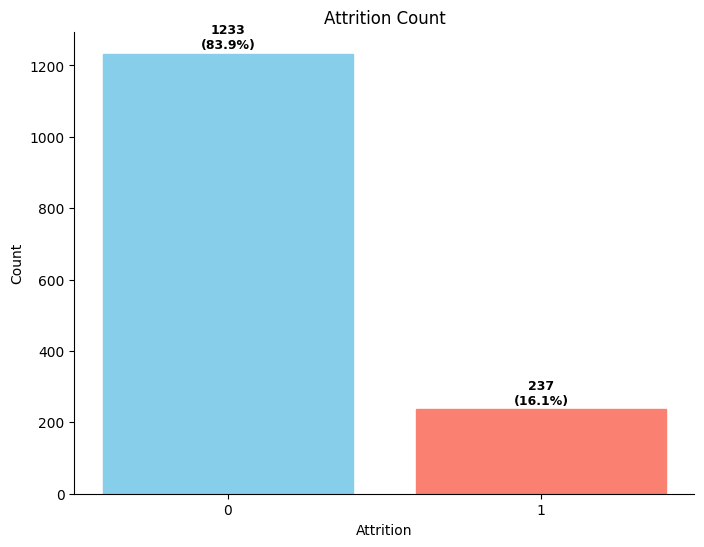

In [27]:

counts_attrition = df['Attrition'].value_counts().sort_index()

plt.figure(figsize=(8, 6))

bars = plt.bar(counts_attrition.index, counts_attrition.values)


colors = ['skyblue', 'salmon']
for bar, color in zip(bars, colors):
    bar.set_color(color)


total = counts_attrition.sum()
for i, v in enumerate(counts_attrition.values):
    percent = round((v / total) * 100, 1)
    
    plt.text(
        i, 
        v + (total * 0.01), 
        f'{v}\n({percent}%)',
        ha='center',
        fontsize=9,
        fontweight='bold'  
    )

plt.xticks([0, 1])

plt.title('Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Count')


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [28]:
df['Age'].value_counts().sort_values(ascending=False)

Age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
38    58
33    58
40    57
37    50
28    48
27    48
42    46
39    42
45    41
41    40
26    39
44    33
46    33
43    32
50    30
25    26
24    26
49    24
47    24
55    22
48    19
51    19
53    19
54    18
52    18
22    16
56    14
58    14
23    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: count, dtype: int64

In [29]:
df['Age'].unique()

array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
       24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
       58, 20, 25, 19, 57, 52, 47, 18, 60])

- binning age feature 

In [30]:
bins=[18,20,30,40,50,60]
labels=['18-20','20-30','30-40','40-50','50-60']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels,right=False)
df['Age_Group'].value_counts().sort_index()

Age_Group
18-20     17
20-30    309
30-40    622
40-50    349
50-60    168
Name: count, dtype: int64

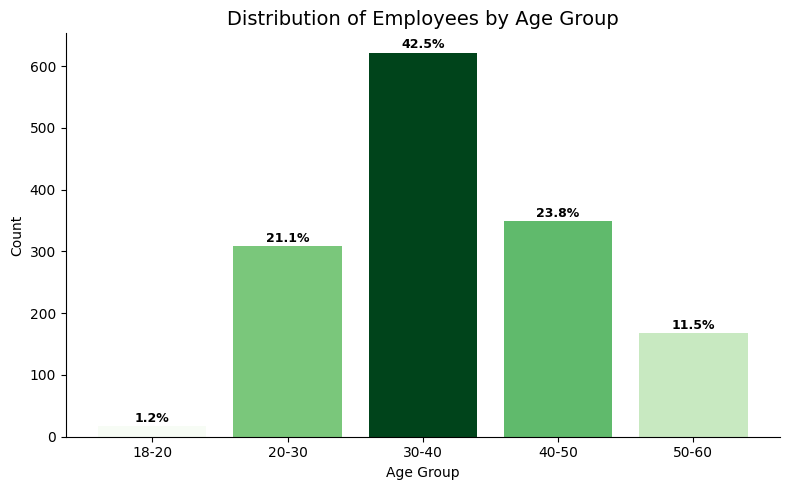

In [31]:

from matplotlib import cm
from matplotlib.colors import Normalize


age_counts = df['Age_Group'].value_counts().sort_index()

percentages = age_counts / age_counts.sum() * 100


norm = Normalize(
    vmin=age_counts.min(),
    vmax=age_counts.max()
)


colors = cm.Greens(norm(age_counts.values))


fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    age_counts.index.astype(str),
    age_counts.values,
    color=colors
)


for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold' 
    )


ax.set_title('Distribution of Employees by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)




plt.tight_layout()
plt.show()

In [32]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Age_Group
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,1,40-50
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,1,0,40-50
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,1,30-40
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,1,0,30-40
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,1,0,20-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,1,0,0,0,0,0,0,1,0,30-40
1466,39,0,613,6,1,4,1,42,2,3,...,0,0,0,0,0,0,0,1,0,30-40
1467,27,0,155,4,3,2,1,87,4,2,...,0,0,1,0,0,0,0,1,0,20-30
1468,49,0,1023,2,3,4,1,63,2,2,...,0,0,0,0,0,1,0,1,0,40-50


In [33]:
df['DailyRate'].describe().round(2)

count    1470.00
mean      802.49
std       403.51
min       102.00
25%       465.00
50%       802.00
75%      1157.00
max      1499.00
Name: DailyRate, dtype: float64

In [34]:
df['DistanceFromHome'].describe().round(2)

count    1470.00
mean        9.19
std         8.11
min         1.00
25%         2.00
50%         7.00
75%        14.00
max        29.00
Name: DistanceFromHome, dtype: float64

<Axes: >

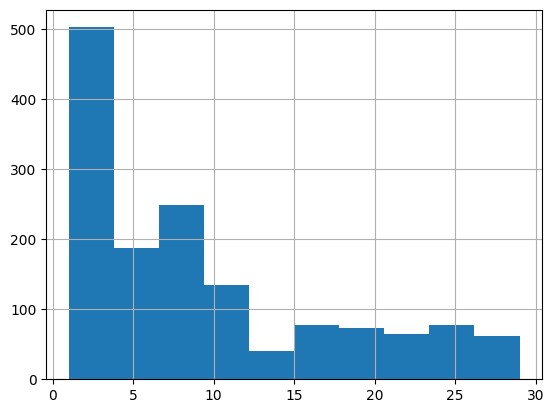

In [35]:
df['DistanceFromHome'].hist()

<Axes: xlabel='DistanceFromHome'>

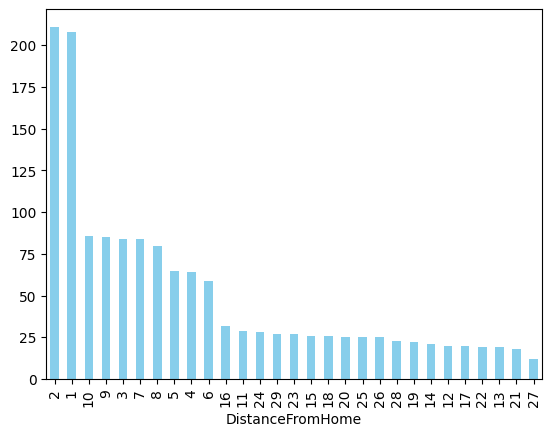

In [36]:
df['DistanceFromHome'].value_counts().plot(kind='bar',color='skyblue')

In [37]:
df['DistanceFromHome']=pd.cut(df['DistanceFromHome'],bins=[1,10,20,30],labels=['Near','Medium','Far'])


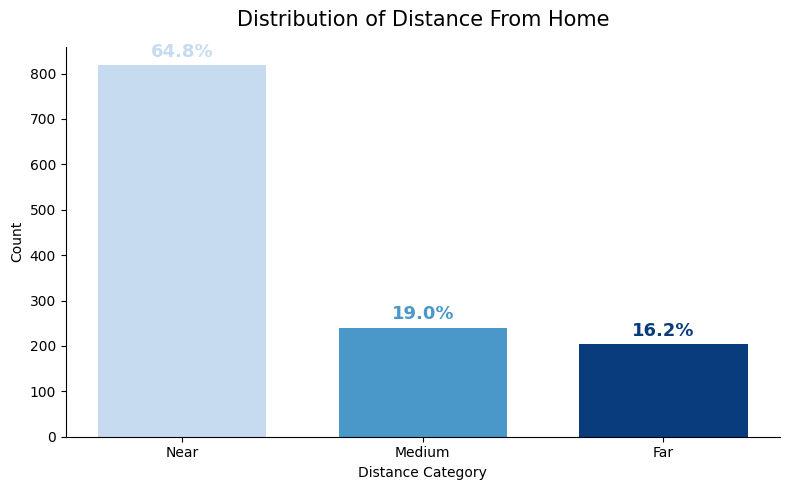

In [38]:


dist_counts = df['DistanceFromHome'].value_counts().sort_index()
percentages = dist_counts / dist_counts.sum() * 100#
colors = cm.Blues(np.linspace(0.25, 0.95, len(dist_counts)))

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    dist_counts.index,
    dist_counts.values,
    color=colors,
    width=0.7
)


for bar, pct in zip(bars, percentages):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color=bar.get_facecolor()  
    )

ax.set_title(
    'Distribution of Distance From Home',
    fontsize=15,
    pad=15
)

ax.set_xlabel('Distance Category')
ax.set_ylabel('Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.grid(False)

plt.tight_layout()
plt.show()

In [39]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobR

In [40]:
df['Education'].value_counts().sort_index()

Education
1    170
2    282
3    572
4    398
5     48
Name: count, dtype: int64

In [41]:
df['Education']=pd.cut(df['Education'],bins=[0,1,2,3,4,5],labels=['Below College','College','Bachelor','Master','Doctor'])

<Axes: xlabel='Education'>

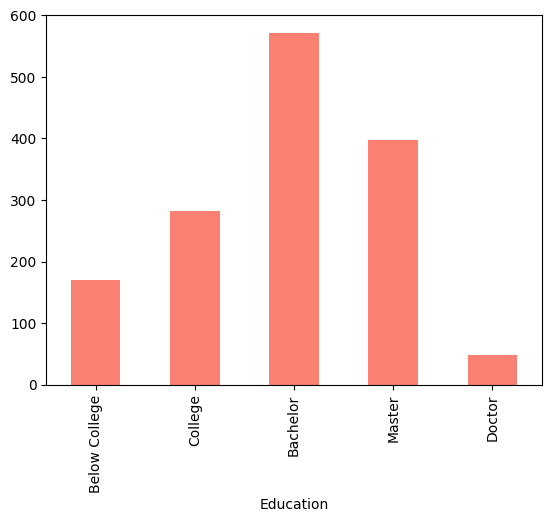

In [42]:
df['Education'].value_counts().sort_index().plot(kind='bar',color='salmon')

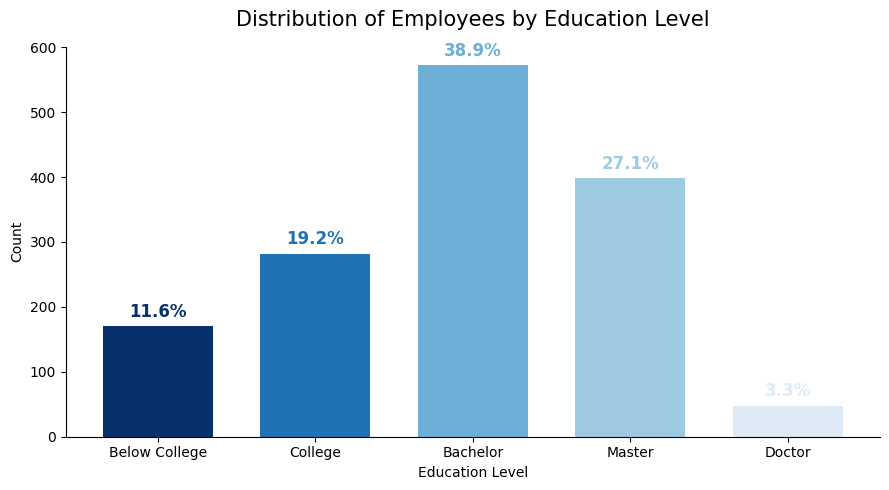

In [ ]:


edu_counts = df['Education'].value_counts().sort_index()

percentages = edu_counts / edu_counts.sum() * 100

colors = [
    '#08306b',
    '#2171b5',
    '#6baed6',
    '#9ecae1',
    '#deebf7'
]

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    edu_counts.index,
    edu_counts.values,
    color=colors,
    width=0.7
)


for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 8,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color=bar.get_facecolor()
    )

ax.set_title(
    'Distribution of Employees by Education Level',
    fontsize=15,
    pad=15
)

ax.set_xlabel('Education Level')
ax.set_ylabel('Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.grid(False)

plt.tight_layout()
plt.show()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Age_Group
0,41,1,1102,NaN,College,2,0,94,3,2,...,0,0,0,0,0,1,0,0,1,40-50
1,49,0,279,Near,Below College,3,1,61,2,2,...,0,0,0,0,1,0,0,1,0,40-50
2,37,1,1373,Near,College,4,1,92,2,1,...,1,0,0,0,0,0,0,0,1,30-40
3,33,0,1392,Near,Master,4,0,56,3,1,...,0,0,0,0,1,0,0,1,0,30-40
4,27,0,591,Near,Below College,1,1,40,3,1,...,1,0,0,0,0,0,0,1,0,20-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,Far,College,3,1,41,4,2,...,1,0,0,0,0,0,0,1,0,30-40
1466,39,0,613,Near,Below College,4,1,42,2,3,...,0,0,0,0,0,0,0,1,0,30-40
1467,27,0,155,Near,Bachelor,2,1,87,4,2,...,0,0,1,0,0,0,0,1,0,20-30
1468,49,0,1023,Near,Bachelor,4,1,63,2,2,...,0,0,0,0,0,1,0,1,0,40-50


In [ ]:
df['EnvironmentSatisfaction'].value_counts().sort_index()

EnvironmentSatisfaction
1    284
2    287
3    453
4    446
Name: count, dtype: int64

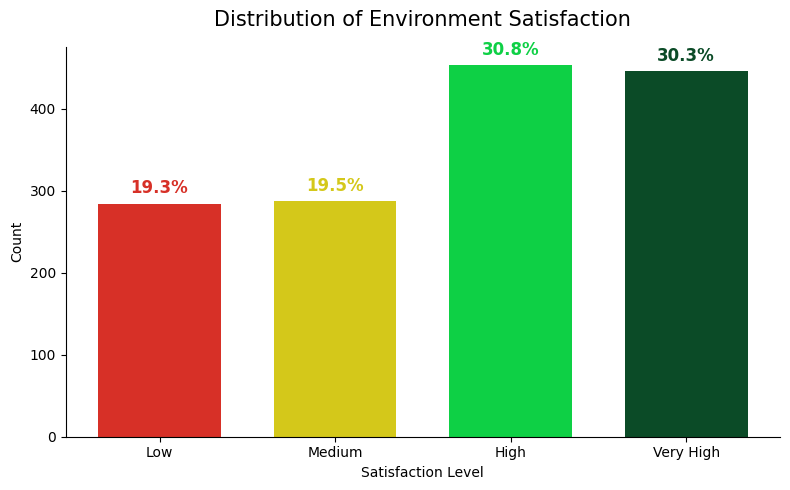

In [ ]:


env_counts = df['EnvironmentSatisfaction'].value_counts().sort_index()

labels = ['Low', 'Medium', 'High', 'Very High']
percentages = env_counts / env_counts.sum() * 100

colors = [
    '#d73027',  # Low
    "#d4c81a",  # Medium
    "#0ed045",  # High
    "#0b4b27"   # Very High
]

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    labels,
    env_counts.values,
    color=colors,
    width=0.7
)

# درصدها
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 8,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color=bar.get_facecolor()
    )

ax.set_title(
    'Distribution of Environment Satisfaction',
    fontsize=15,
    pad=15
)

ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Count')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.grid(False)

plt.tight_layout()
plt.show()

In [51]:
df.shape

(1470, 46)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                1470 non-null   int64   
 1   Attrition                          1470 non-null   int64   
 2   DailyRate                          1470 non-null   int64   
 3   DistanceFromHome                   1262 non-null   category
 4   Education                          1470 non-null   category
 5   EnvironmentSatisfaction            1470 non-null   int64   
 6   Gender                             1470 non-null   int64   
 7   HourlyRate                         1470 non-null   int64   
 8   JobInvolvement                     1470 non-null   int64   
 9   JobLevel                           1470 non-null   int64   
 10  JobSatisfaction                    1470 non-null   int64   
 11  MonthlyIncome                      1470 non

In [54]:
df['Education'] = df['Education'].cat.codes + 1
df['DistanceFromHome'] = df['DistanceFromHome'].map({'Near': 5, 'Medium': 15, 'Far': 25})

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Age                                1470 non-null   int64   
 1   Attrition                          1470 non-null   int64   
 2   DailyRate                          1470 non-null   int64   
 3   DistanceFromHome                   1262 non-null   category
 4   Education                          1470 non-null   int8    
 5   EnvironmentSatisfaction            1470 non-null   int64   
 6   Gender                             1470 non-null   int64   
 7   HourlyRate                         1470 non-null   int64   
 8   JobInvolvement                     1470 non-null   int64   
 9   JobLevel                           1470 non-null   int64   
 10  JobSatisfaction                    1470 non-null   int64   
 11  MonthlyIncome                      1470 non

In [56]:
df['Education'].value_counts().sort_index()

Education
1    170
2    282
3    572
4    398
5     48
Name: count, dtype: int64

In [ ]:
df['DistanceFromHome'].value_counts().sort_index() 

DistanceFromHome
5     818
15    240
25    204
Name: count, dtype: int64

In [59]:
df['Gender'].value_counts().sort_index()

Gender
0    588
1    882
Name: count, dtype: int64

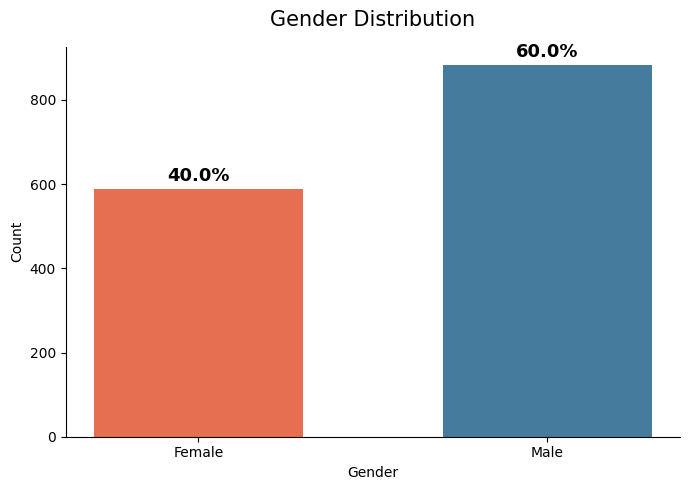

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts().sort_index()


labels = ['Female', 'Male']  

percentages = gender_counts / gender_counts.sum() * 100

colors = ['#e76f51', '#457b9d']

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    labels,
    gender_counts.values,
    color=colors,
    width=0.6
)


for bar, pct in zip(bars, percentages):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

ax.set_title(
    'Gender Distribution',
    fontsize=15,
    pad=15
)

ax.set_xlabel('Gender')
ax.set_ylabel('Count')ی
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)

plt.tight_layout()
plt.show()